## Práctica 2 - Parte 2 - Análisis Estadístico de Señales 

### Presentado por: Alma Olea Barbosa - Lauren Cordero Ramos 

#### Semestre: 2026-2 

In [37]:
# Librerías necesarias
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RUTA_DIAGNOSTICOS = "Diagnostics.xlsx"      # archivo de etiquetas
RUTA_SEÑALES = r"C:\Users\corde\OneDrive\Imágenes\Escritorio\Bioseñales\ECGDataDenoised"  # carpeta con los MUSE_*.csv

# Función auxiliar para mostrar tablas más organizadas y legibles
def tabla_bonita(df):
    return (df.style
            .hide(axis='index')  # quita el índice numérico 0,1,2...
            .set_table_styles([
                {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                              ('color', '#AEE2FF'),  # celeste claro
                                              ('font-weight', 'bold'),
                                              ('text-align', 'left'),
                                              ('padding', '8px')]},
                {'selector': 'td', 'props': [('background-color', '#ffffff'),
                                              ('color', '#1a1a1a'),  # texto oscuro, siempre legible
                                              ('padding', '8px'),
                                              ('text-align', 'left')]},
                {'selector': 'tr:nth-child(even) td', 'props': [('background-color', '#e8eef3'),
                                                                 ('color', '#1a1a1a')]},
            ])
            .set_properties(**{'white-space': 'normal', 'max-width': '400px'}))


---
## 1. Exploración y descripción de la base de datos


In [10]:
# Cargar el archivo de diagnósticos (metadatos de cada registro)
diagnosticos = pd.read_excel(RUTA_DIAGNOSTICOS)
tabla_bonita(diagnosticos.head())


FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


### 1.1 Número total de registros y sujetos

In [11]:
n_registros = diagnosticos.shape[0]
n_sujetos = diagnosticos['FileName'].nunique()  # cada archivo corresponde a un registro/sujeto único

tabla_general = pd.DataFrame({
    'Descripción': ['Número total de registros', 'Número total de sujetos (archivos únicos)'],
    'Valor': [n_registros, n_sujetos]
})
tabla_bonita(tabla_general)


Descripción,Valor
Número total de registros,10646
Número total de sujetos (archivos únicos),10646


**Nota:** en esta base de datos cada registro corresponde a un sujeto distinto (no hay sujetos con múltiples 
adquisiciones identificadas), por lo que el número de registros y de sujetos coincide.


### 1.2 Tipos de arritmias o clases disponibles

In [12]:
# Diccionario de referencia con el significado de cada abreviatura (Rhythm)
significado_ritmos = {
    'SB':    'Bradicardia sinusal (Sinus Bradycardia)',
    'SR':    'Ritmo sinusal normal (Sinus Rhythm)',
    'AFIB':  'Fibrilación auricular (Atrial Fibrillation)',
    'ST':    'Taquicardia sinusal (Sinus Tachycardia)',
    'SVT':   'Taquicardia supraventricular (Supraventricular Tachycardia)',
    'AF':    'Aleteo/Flutter auricular (Atrial Flutter)',
    'SA':    'Arritmia sinusal (Sinus Irregularity)',
    'AT':    'Taquicardia auricular (Atrial Tachycardia)',
    'AVNRT': 'Taquicardia por reentrada nodal AV (AV Nodal Reentrant Tachycardia)',
    'AVRT':  'Taquicardia por reentrada AV (AV Reentrant Tachycardia)',
    'SAAWR': 'Ritmo auricular migratorio/marcapasos auricular errante (Sinus Atrium to Atrial Wandering Rhythm)'
}

tabla_clases = pd.DataFrame({
    'Código': significado_ritmos.keys(),
    'Descripción': significado_ritmos.values()
})
tabla_bonita(tabla_clases)


Código,Descripción
SB,Bradicardia sinusal (Sinus Bradycardia)
SR,Ritmo sinusal normal (Sinus Rhythm)
AFIB,Fibrilación auricular (Atrial Fibrillation)
ST,Taquicardia sinusal (Sinus Tachycardia)
SVT,Taquicardia supraventricular (Supraventricular Tachycardia)
AF,Aleteo/Flutter auricular (Atrial Flutter)
SA,Arritmia sinusal (Sinus Irregularity)
AT,Taquicardia auricular (Atrial Tachycardia)
AVNRT,Taquicardia por reentrada nodal AV (AV Nodal Reentrant Tachycardia)
AVRT,Taquicardia por reentrada AV (AV Reentrant Tachycardia)


### 1.3 Número de sujetos o registros pertenecientes a cada grupo

In [13]:
# Tabla combinada: código, descripción, número de registros y porcentaje sobre el total
conteo_ritmo = diagnosticos['Rhythm'].value_counts().rename_axis('Rhythm').reset_index(name='N_registros')
conteo_ritmo['Descripción'] = conteo_ritmo['Rhythm'].map(significado_ritmos)
conteo_ritmo['Porcentaje (%)'] = (conteo_ritmo['N_registros'] / n_registros * 100).round(2)
conteo_ritmo = conteo_ritmo[['Rhythm', 'Descripción', 'N_registros', 'Porcentaje (%)']]
tabla_bonita(conteo_ritmo)


Rhythm,Descripción,N_registros,Porcentaje (%)
SB,Bradicardia sinusal (Sinus Bradycardia),3889,36.530000
SR,Ritmo sinusal normal (Sinus Rhythm),1826,17.150000
AFIB,Fibrilación auricular (Atrial Fibrillation),1780,16.720000
ST,Taquicardia sinusal (Sinus Tachycardia),1568,14.730000
SVT,Taquicardia supraventricular (Supraventricular Tachycardia),587,5.510000
AF,Aleteo/Flutter auricular (Atrial Flutter),445,4.180000
SA,Arritmia sinusal (Sinus Irregularity),399,3.750000
AT,Taquicardia auricular (Atrial Tachycardia),121,1.140000
AVNRT,Taquicardia por reentrada nodal AV (AV Nodal Reentrant Tachycardia),16,0.150000
AVRT,Taquicardia por reentrada AV (AV Reentrant Tachycardia),8,0.080000


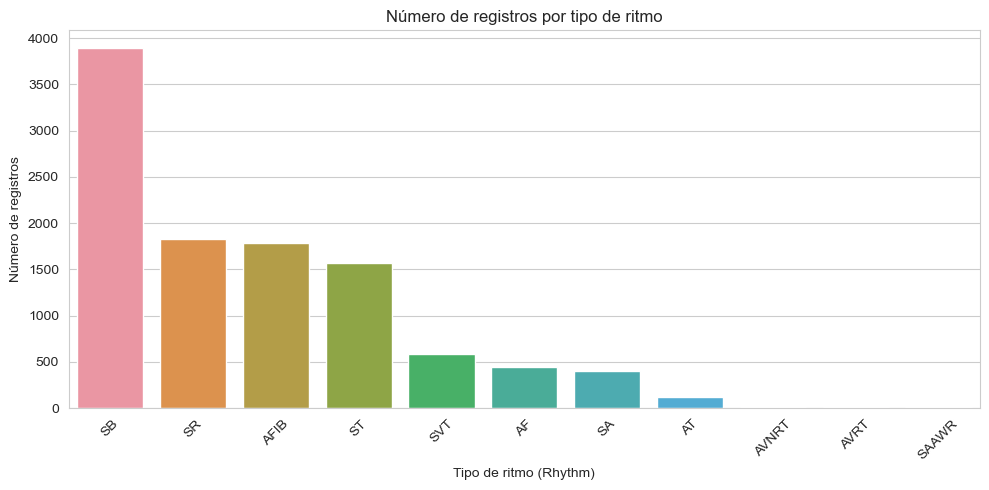

In [14]:
# Visualización de la distribución de clases por tipo de ritmo
plt.figure(figsize=(10, 5))
sns.barplot(data=conteo_ritmo, x='Rhythm', y='N_registros', order=conteo_ritmo['Rhythm'])
plt.title('Número de registros por tipo de ritmo')
plt.xlabel('Tipo de ritmo (Rhythm)')
plt.ylabel('Número de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis:** la base de datos está fuertemente desbalanceada. Las clases **SB** (bradicardia sinusal), 
**SR** (ritmo sinusal) y **AFIB** (fibrilación auricular) concentran la mayoría de los registros, mientras que 
clases como **AVNRT**, **AVRT** y **SAAWR** tienen muy pocos registros (menos de 20), lo cual debe tenerse en 
cuenta al seleccionar los grupos a comparar estadísticamente más adelante.

### 1.4 Número de canales disponibles y sus derivaciones

In [15]:
# Se lee un registro de ejemplo para verificar el número de canales
archivo_ejemplo = diagnosticos['FileName'].iloc[0] + '.csv'
ruta_ejemplo = os.path.join(RUTA_SEÑALES, archivo_ejemplo)

señal_ejemplo = pd.read_csv(ruta_ejemplo, header=None)
n_muestras, n_canales = señal_ejemplo.shape

nombres_derivaciones = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                         'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

tabla_canales = pd.DataFrame({
    'N° de canal': range(1, n_canales + 1),
    'Derivación': nombres_derivaciones
})
tabla_bonita(tabla_canales)


N° de canal,Derivación
1,I
2,II
3,III
4,aVR
5,aVL
6,aVF
7,V1
8,V2
9,V3
10,V4


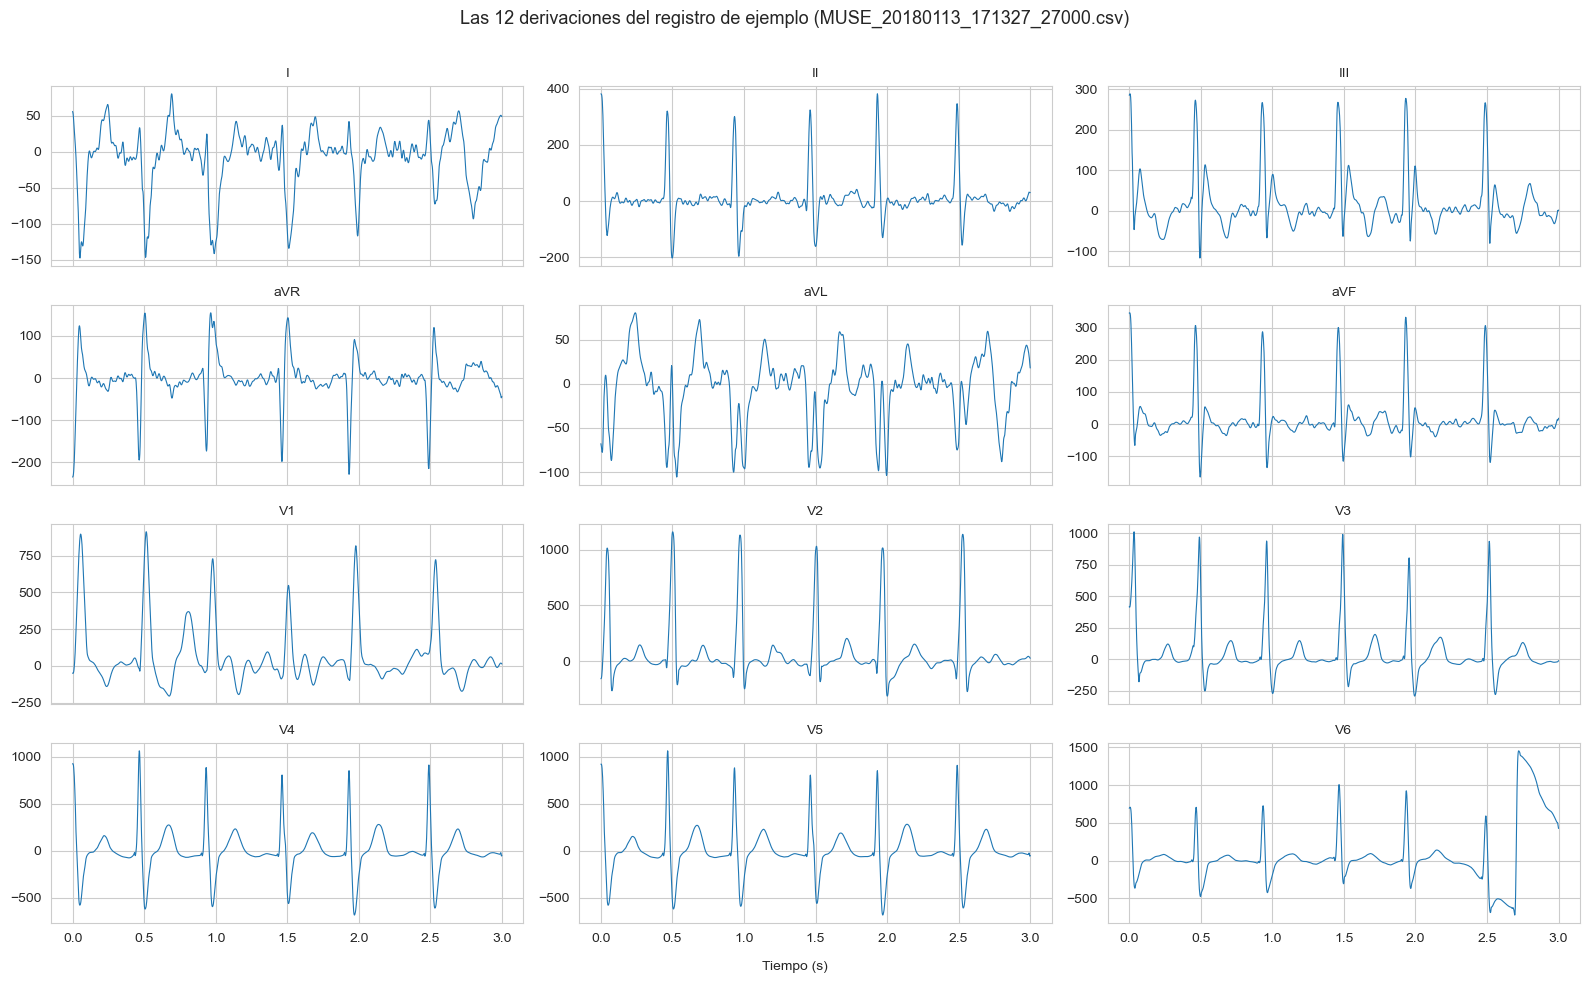

In [16]:
# Visualización rápida de las 12 derivaciones del registro de ejemplo (primeros 3 segundos)
fs_temporal = 500
t_ejemplo = np.arange(señal_ejemplo.shape[0]) / fs_temporal
mask_ejemplo = t_ejemplo <= 3

fig, axs = plt.subplots(4, 3, figsize=(16, 10), sharex=True)
for i, ax in enumerate(axs.flat):
    ax.plot(t_ejemplo[mask_ejemplo], señal_ejemplo[i][mask_ejemplo], linewidth=0.8)
    ax.set_title(nombres_derivaciones[i], fontsize=10)
fig.suptitle(f'Las 12 derivaciones del registro de ejemplo ({archivo_ejemplo})', fontsize=13)
fig.text(0.5, 0.02, 'Tiempo (s)', ha='center')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


### 1.5 Frecuencia de muestreo y duración de los registros

In [17]:
fs = 500  # Hz, frecuencia de muestreo reportada para la base de datos ChapmanECG
duracion_s = n_muestras / fs

tabla_adquisicion = pd.DataFrame({
    'Parámetro': ['Frecuencia de muestreo', 'Muestras por registro', 'Duración por registro'],
    'Valor': [f"{fs} Hz", n_muestras, f"{duracion_s} s"]
})
tabla_bonita(tabla_adquisicion)


Parámetro,Valor
Frecuencia de muestreo,500 Hz
Muestras por registro,5000
Duración por registro,10.0 s


## 2. Visualización y caracterización de las señales

Se seleccionan dos registros pertenecientes a dos tipos de arritmia distintos para comparar su morfología, 
amplitud, frecuencia cardíaca y regularidad.


### Selección de registros

Se seleccionan dos arritmias con buen número de muestras en la base de datos:

- **AFIB** — Fibrilación auricular: ausencia de ondas P organizadas, actividad auricular caótica (ondas 
  fibrilatorias) y respuesta ventricular **irregularmente irregular** (intervalos RR variables).
- **SB** — Bradicardia sinusal: ritmo de origen sinusal (ondas P normales seguidas de complejo QRS), pero con 
  frecuencia cardíaca por debajo de 60 lpm; el ritmo es regular.


In [18]:
# Selección de un registro representativo de cada clase
clase_1, clase_2 = 'AFIB', 'SB'

registro_1 = diagnosticos[diagnosticos['Rhythm'] == clase_1].iloc[0]
registro_2 = diagnosticos[diagnosticos['Rhythm'] == clase_2].iloc[0]

print(f"Registro clase {clase_1}: {registro_1['FileName']} | FC reportada: {registro_1['VentricularRate']} lpm")
print(f"Registro clase {clase_2}: {registro_2['FileName']} | FC reportada: {registro_2['VentricularRate']} lpm")


Registro clase AFIB: MUSE_20180113_171327_27000 | FC reportada: 117 lpm
Registro clase SB: MUSE_20180112_073319_29000 | FC reportada: 52 lpm


In [19]:
def cargar_señal(nombre_archivo, ruta=RUTA_SEÑALES):
    ruta_completa = os.path.join(ruta, nombre_archivo + '.csv')
    datos = pd.read_csv(ruta_completa, header=None)
    datos.columns = nombres_derivaciones
    return datos

señal_1 = cargar_señal(registro_1['FileName'])
señal_2 = cargar_señal(registro_2['FileName'])

fs = 500
t = np.arange(señal_1.shape[0]) / fs   # vector de tiempo (10 s para ambos registros)

# Derivación II es la más usada para análisis de ritmo
lead = 'II'


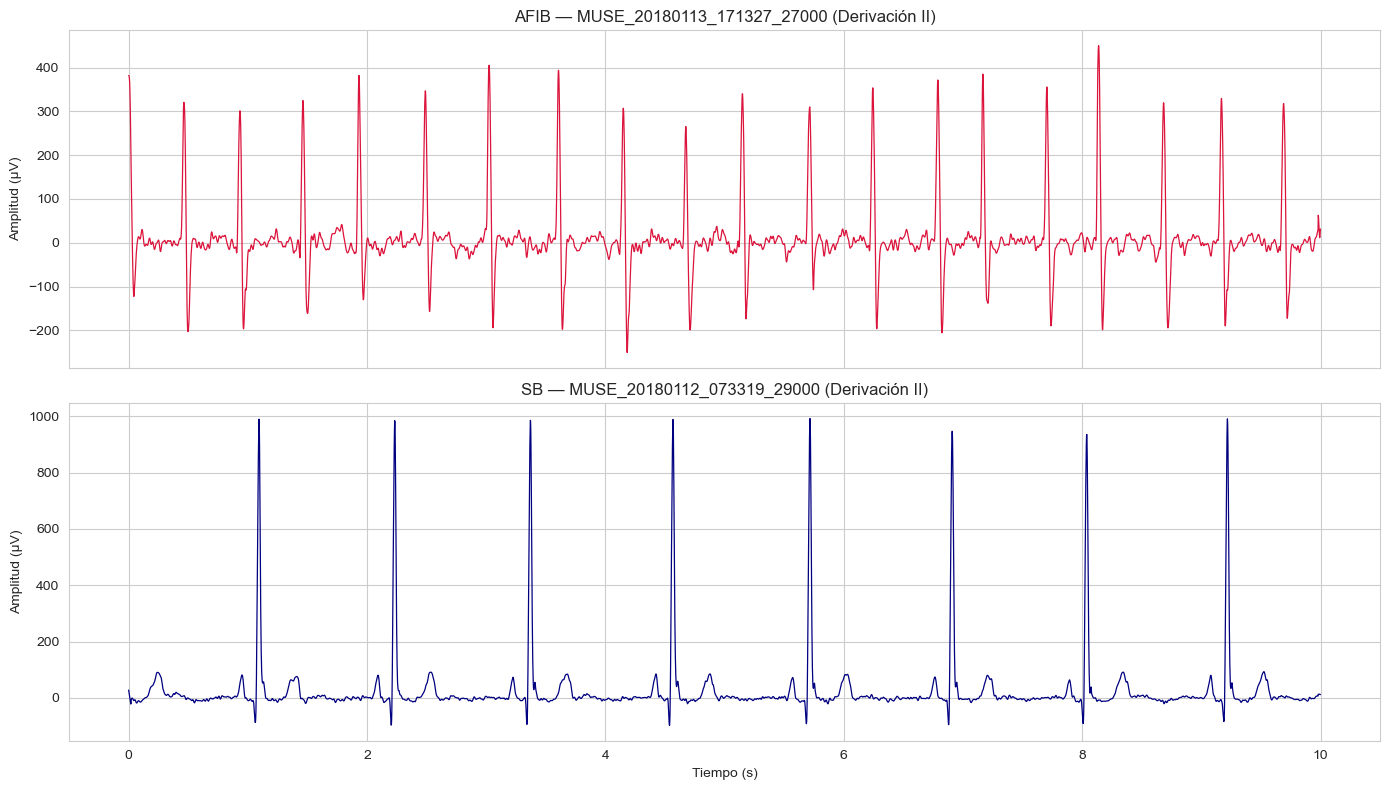

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(t, señal_1[lead], color='crimson', linewidth=0.9)
axs[0].set_title(f"{clase_1} — {registro_1['FileName']} (Derivación {lead})")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t, señal_2[lead], color='navy', linewidth=0.9)
axs[1].set_title(f"{clase_2} — {registro_2['FileName']} (Derivación {lead})")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud (µV)")

plt.tight_layout()
plt.show()


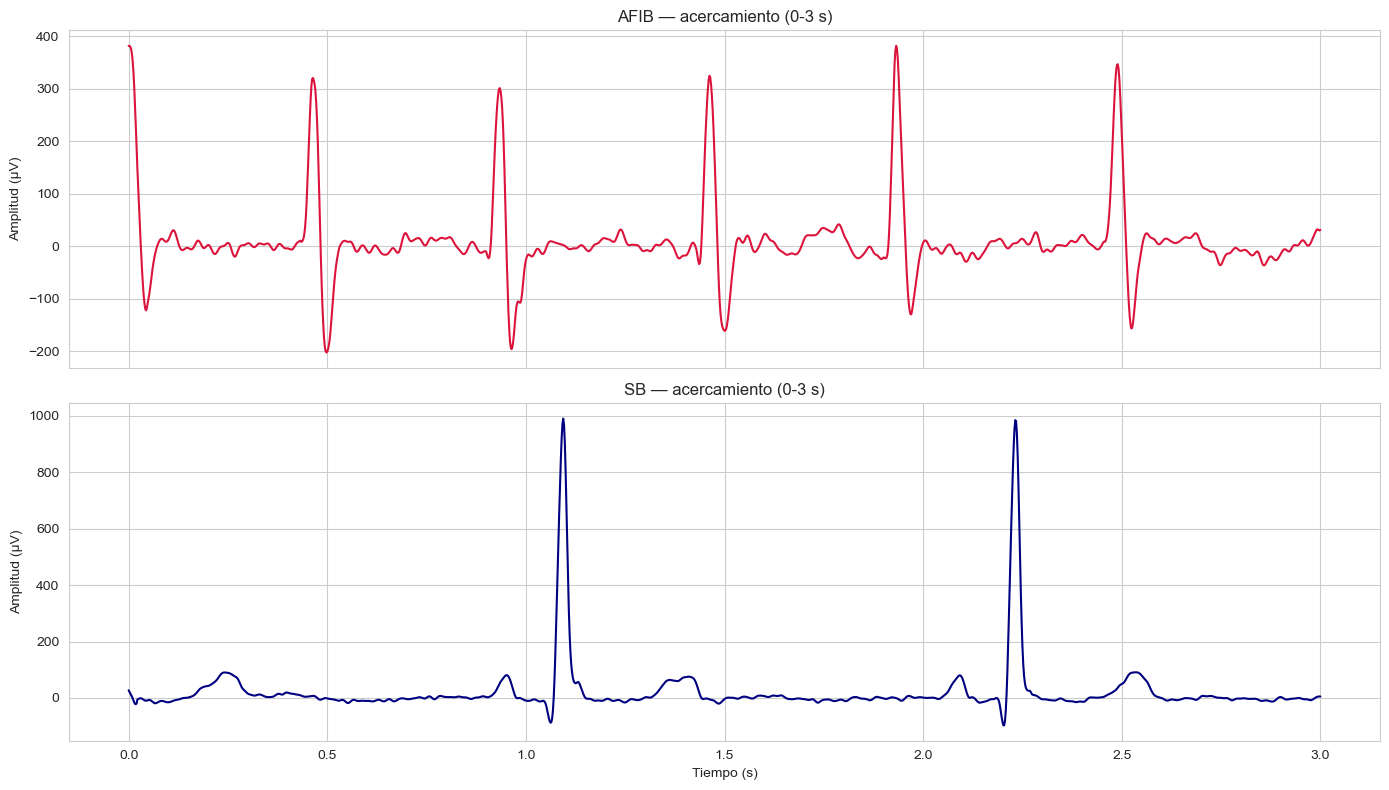

In [21]:
# Acercamiento a los primeros 3 segundos para observar mejor la morfología de los latidos
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

mask = t <= 3

axs[0].plot(t[mask], señal_1[lead][mask], color='crimson')
axs[0].set_title(f"{clase_1} — acercamiento (0-3 s)")
axs[0].set_ylabel("Amplitud (µV)")

axs[1].plot(t[mask], señal_2[lead][mask], color='navy')
axs[1].set_title(f"{clase_2} — acercamiento (0-3 s)")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud (µV)")

plt.tight_layout()
plt.show()


### 2.2 Análisis por inspección visual: morfología, amplitud, frecuencia cardíaca y regularidad

**Morfología:** al observar el registro de bradicardia sinusal (SB), se distingue con claridad la secuencia 
característica onda P – complejo QRS – onda T en cada latido, repitiéndose de forma consistente a lo largo de 
todo el registro. En el registro de fibrilación auricular (AFIB), en cambio, no es posible identificar una onda 
P organizada antes de cada QRS; en su lugar, la línea de base se ve ondulada e irregular (actividad fibrilatoria 
auricular), mientras que el complejo QRS conserva una forma similar a la del ritmo sinusal.

**Amplitud:** a simple vista, la amplitud del complejo QRS es comparable entre ambos registros, sin diferencias 
marcadas en la altura de los picos. Esto es esperable, ya que la amplitud depende principalmente de la posición 
de los electrodos y de la masa ventricular, no del tipo de arritmia auricular presente. Sí pueden notarse 
pequeñas diferencias en la línea de base (más ondulada en AFIB por la actividad auricular caótica).


**Regularidad:** este es el aspecto más distintivo entre ambas señales. En el registro SB, la distancia entre 
picos R consecutivos se ve prácticamente constante a lo largo de todo el trazo, lo que indica un ritmo 
**regular**. En el registro AFIB, por el contrario, la distancia entre picos R varía notoriamente de un latido a 
otro sin un patrón fijo, lo cual es visualmente evidente al comparar los espacios entre picos en distintas partes 
de la señal. Este comportamiento corresponde al patrón clínicamente descrito como **"irregularmente irregular"**, 
uno de los signos característicos de la fibrilación auricular.




## 3. Análisis estadístico entre arritmias 

### 3.1 Calcule y compare mediante un análisis descriptivo las características descriptivas


In [46]:
n_muestra = 40  # cuántos sujetos tomar de cada clase

# Se eligen al azar n_muestra archivos de cada clase (grupo 1 y grupo 2)
archivos_c1 = diagnosticos[diagnosticos['Rhythm'] == clase_1].sample(n=n_muestra, random_state=42)['FileName'].tolist()
archivos_c2 = diagnosticos[diagnosticos['Rhythm'] == clase_2].sample(n=n_muestra, random_state=42)['FileName'].tolist()

# Aquí vamos a ir guardando los resultados de cada archivo
lista_datos = []

# Función que calcula las 5 características de UNA señal
def calcular_caract(nombre_archivo, clase):
    señal = cargar_señal(nombre_archivo)[lead].values.astype(float)

    media = np.mean(señal)
    desviacion = np.std(señal)
    maximo = np.max(señal)
    minimo = np.min(señal)
    rms = np.sqrt(np.mean(señal**2))

    return [nombre_archivo, clase, media, desviacion, maximo, minimo, rms]

# Recorremos los archivos del grupo 1 y guardamos sus datos
for archivo in archivos_c1:
    datos = calcular_caract(archivo, clase_1)
    lista_datos.append(datos)

# Recorremos los archivos del grupo 2 y guardamos sus datos
for archivo in archivos_c2:
    datos = calcular_caract(archivo, clase_2)
    lista_datos.append(datos)

# Convertimos la lista en una tabla (DataFrame)
df_caract = pd.DataFrame(lista_datos, columns=['Archivo', 'Clase', 'Media', 'Desviacion', 'Maximo', 'Minimo', 'RMS'])

In [30]:
# tabla con el promedio de cada variable por grupo
df_caract.groupby('Clase')[['Media', 'Desviacion', 'Maximo', 'Minimo', 'RMS']].mean()

,Media,Desviacion,Maximo,Minimo,RMS
Clase,,,,,
AFIB,23.647644,125.112417,741.396000,-293.40990,129.197602
SB,31.965252,113.346419,834.830325,-154.35465,118.439275


#### 3.1.1 Media

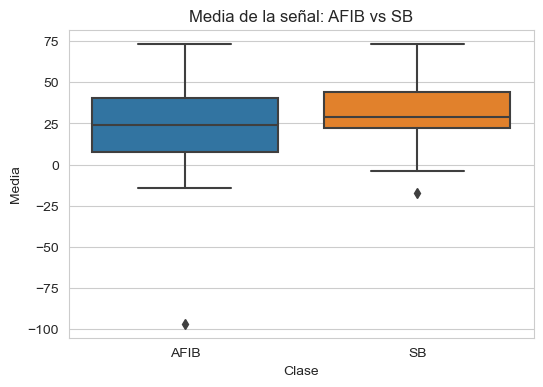

In [31]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_caract, x='Clase', y='Media')
plt.title('Media de la señal: AFIB vs SB')
plt.show()

Aunque SB presenta una media global superior (31.96 frente a 23.64 de AFIB). La dispersión de ambas distribuciones en los datos individuales es similar, por lo que visualmente no se aprecia una separación marcada entre los grupos basándose únicamente en esta característica.

#### 3.1.2 Desviación estándar 

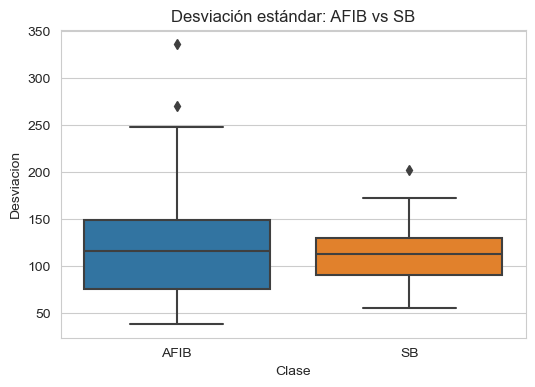

In [33]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_caract, x='Clase', y='Desviacion')
plt.title('Desviación estándar: AFIB vs SB')
plt.show()

Existe una superposición considerable entre ambas clases, pero se nota que la dispersión tiende a ser ligeramente mayor en la clase AFIB (media de 125.11) en comparación con SB (113.34). Visualmente, aunque AFIB tiene algunos valores extremos más altos, las distribuciones centrales se solapan demasiado para separar los grupos.

#### 3.1.3 Máximos

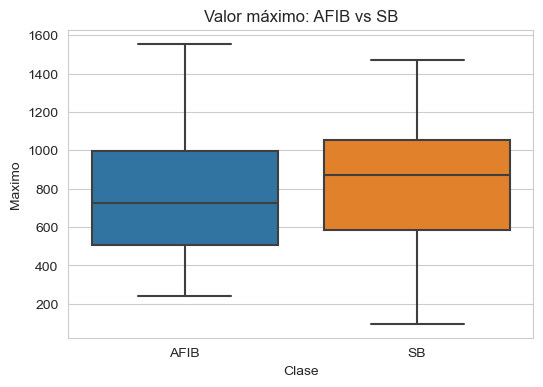

In [47]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_caract, x='Clase', y='Maximo')
plt.title('Valor máximo: AFIB vs SB')
plt.show()

Ambas clases abarcan un rango de valores máximos muy amplio, aunque el promedio de los picos máximos es mayor en SB (834.83) respecto a AFIB (741.39), la enorme varianza dentro de la misma clase (con picos que van desde los 240 hasta más de 1500 en AFIB) impide que haya una discriminación directa entre las dos patologías.

#### 3.1.4 Mínimo

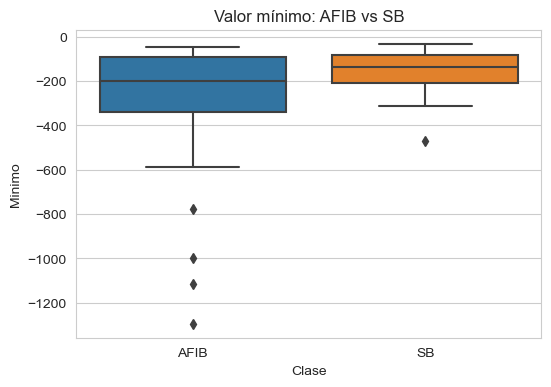

In [35]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_caract, x='Clase', y='Minimo')
plt.title('Valor mínimo: AFIB vs SB')
plt.show()

En esta gráfica se aprecia que los valores mínimos (picos negativos) alcanzan magnitudes más profundas en la clase AFIB (promedio de -293.41) frente a SB (-154.35). Aunque existe cierta superposición natural, esta clara diferencia central evidencia un comportamiento distinto entre los grupos.

#### 3.1.5 RMS

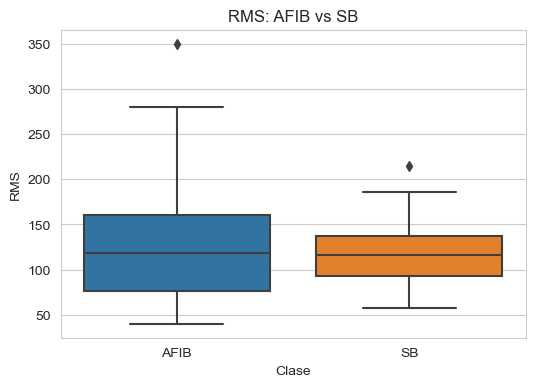

In [36]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_caract, x='Clase', y='RMS')
plt.title('RMS: AFIB vs SB')
plt.show()

Al igual que ocurre con la desviación estándar, el RMS muestra un gran solapamiento entre los grupos. La clase AFIB tiende a presentar valores superiores en promedio (129.19) respecto a SB (118.43). Visualmente, las "cajas" o distribuciones de ambos grupos se verían muy alineadas, sin ofrecer una frontera de separación evidente.

### 3.2 Formular la hipótesis nula y la hipótesis alterna

De las cinco variables analizadas, se observó que la
variable **Mínimo** es la que presenta la separación más clara entre los grupos AFIB y SB: las medianas
están más distanciadas (-210 vs -140), la dispersión es mayor en AFIB, y este grupo presenta varios valores
atípicos muy extremos (hasta -1300) que casi no se observan en SB. Las demás variables (media, desviación
estándar, máximo y RMS) muestran cajas fuertemente solapadas entre ambos grupos, por lo que no ofrecen
evidencia visual clara de diferencia y no se seleccionan para la prueba de hipótesis.

Por lo tanto, se plantea la siguiente hipótesis usando el **valor mínimo** de la señal ECG:

- **H₀ (hipótesis nula):** no existe diferencia estadísticamente significativa en el valor mínimo de la señal ECG entre los pacientes AFIB y los pacientes SB
- **H₁ (hipótesis alternativa):** sí existe diferencia estadísticamente significativa en el valor mínimo de la señal ECG entre ambos grupos

Se utilizará un nivel de significancia α = 0.05.

## 4. Comprobar los supuestos y aplicar la prueba correcta

In [38]:
# Separamos los valores de "Minimo" de cada grupo (AFIB y SB)
minimo_afib = df_caract[df_caract['Clase'] == clase_1]['Minimo']
minimo_sb = df_caract[df_caract['Clase'] == clase_2]['Minimo']

#### Prueba de normalidad (Shapiro-Wilk)

In [39]:
# la hipótesis nula es "los datos SÍ son normales", entonces si p > 0.05, se asume normalidad
shapiro_afib = stats.shapiro(minimo_afib)
shapiro_sb = stats.shapiro(minimo_sb)

print("AFIB -> estadístico:", shapiro_afib.statistic, " p-valor:", shapiro_afib.pvalue)
print("SB   -> estadístico:", shapiro_sb.statistic, " p-valor:", shapiro_sb.pvalue)

AFIB -> estadístico: 0.7529740929603577  p-valor: 8.114934075820202e-07
SB   -> estadístico: 0.9203319549560547  p-valor: 0.007888518273830414


Hipótesis de la prueba de Shapiro-Wilk:
- H0: los datos de la variable Mínimo provienen de una distribución normal.
- H1: los datos de la variable Mínimo NO provienen de una distribución normal.

Se aplicó la prueba de Shapiro-Wilk para evaluar la normalidad del valor mínimo de la señal ECG en cada
grupo, con un nivel de significancia α = 0.05. Se obtuvo un estadístico = 0.7530 y p-valor = 8.11e-07 para el grupo AFIB, y un estadístico = 0.9203 y p-valor = 0.00789 para el grupo SB. Como ambos p-valores son menores a α, se rechaza H0 en los dos grupos, por lo que la variable Mínimo NO se distribuye de forma normal ni en AFIB ni en SB.

Dado que la prueba t de Student requiere el cumplimiento del supuesto de normalidad, este supuesto no se cumple para ninguno de los dos grupos. Por esta razón, la prueba t de Student no se selecciona como prueba estadística final. Sin embargo, se procede a evaluar la homocedasticidad mediante la prueba de Levene, con el fin de completar la comprobación de los supuestos solicitados para la comparación estadística.

#### Prueba de homocedasticidad (Levene)

In [43]:
# Levene: prueba si las varianzas de los dos grupos son iguales
# Su hipótesis nula es "las varianzas SÍ son iguales", entonces si p > 0.05, se asume homocedasticidad
levene = stats.levene(minimo_afib, minimo_sb)
print("Levene -> estadístico:", levene.statistic, " p-valor:", levene.pvalue)

Levene -> estadístico: 8.352885481663915  p-valor: 0.004984831946243968


H0: las varianzas de los datos de la variable Mínimo son iguales entre los grupos AFIB y SB.
H1: las varianzas de los datos de la variable Mínimo son diferentes entre los grupos AFIB y SB.

Se aplicó la prueba de Levene para evaluar la homocedasticidad de la variable Mínimo entre los grupos AFIB y SB, utilizando un nivel de significancia α = 0.05. Se obtuvo un estadístico de Levene = 8.3529 y un p-valor = 0.00498. Como el p-valor es menor que α, se rechaza H0. Por lo tanto, se concluye que existen diferencias estadísticamente significativas entre las varianzas de los grupos AFIB y SB, por lo que no se cumple el supuesto de homocedasticidad.

Al evaluar conjuntamente los supuestos, se observa que los datos no cumplen con el supuesto de normalidad, debido a los resultados obtenidos mediante la prueba de Shapiro-Wilk, y tampoco cumplen con el supuesto de homocedasticidad según la prueba de Levene. Por esta razón, no se continúa con una prueba paramétrica como la prueba t de Student. En su lugar, se selecciona la prueba no paramétrica U de Mann-Whitney, ya que permite realizar la comparación entre los dos grupos sin requerir el cumplimiento del supuesto de normalidad.

#### Independencia
Se considera que las observaciones de ambos grupos son independientes debido a que cada registro corresponde a un sujeto diferente y los grupos AFIB y SB están conformados por sujetos distintos. Por tanto, no existen mediciones repetidas del mismo sujeto entre los grupos analizados.

#### Prueba de Mann-Whitney

In [41]:
# Como no se cumplió la normalidad, se usa la prueba no paramétrica U de Mann-Whitney
mannwhitney = stats.mannwhitneyu(minimo_afib, minimo_sb, alternative='two-sided')

print("Estadístico U:", mannwhitney.statistic)
print("p-valor:", mannwhitney.pvalue)

Estadístico U: 566.0
p-valor: 0.02464930835777973


Hipótesis de la prueba U de Mann-Whitney:
- H0: las distribuciones del valor mínimo de la señal ECG son iguales entre los grupos AFIB y SB (no hay diferencia entre las medianas de los dos grupos).
- H1: las distribuciones del valor mínimo de la señal ECG son diferentes entre los grupos AFIB y SB (sí hay diferencia entre las medianas de los dos grupos).

Se aplicó la prueba U de Mann-Whitney con un nivel de significancia α = 0.05, obteniendo un estadístico U = 566.0 y un p-valor = 0.0246. Como el p-valor es menor a α, se rechaza H0: existe una diferencia
estadísticamente significativa en el valor mínimo de la señal ECG entre los pacientes con fibrilación auricular (AFIB) y los pacientes con bradicardia sinusal (SB).

Este resultado es consistente con lo observado en el boxplot: el grupo AFIB presenta valores mínimos más negativos (mediana ≈ -210) que el grupo SB (mediana ≈ -140), además de varios valores atípicos extremos (hasta -1300) que no se observan en SB.

### Conclusiones

1. La exploración de la base de datos evidenció un fuerte desbalance entre clases, concentrándose la
mayoría de los registros en SB, SR y AFIB. 
2. La inspección visual de un registro de cada clase mostró que la diferencia más distintiva entre AFIB y SB es la regularidad del ritmo: mientras SB mantiene intervalos R-R constantes, AFIB presenta un patrón "irregularmente irregular", consistente con la ausencia de ondas P organizadas propia de la fibrilación auricular. 
3. El análisis estadístico de las 5 características descriptivas confirmó que el valor mínimo de la señal fue la única variable con separación clara entre grupos, mientras las demás (media, desviación, máximo, RMS) mostraron fuerte solapamiento.
4. La prueba U de Mann-Whitney respaldó estadísticamente esta diferencia (p = 0.0246 < 0.05), evidenciando que la actividad fibrilatoria caótica de AFIB se traduce en deflexiones negativas más extremas que las del ritmo regular de SB.

### Referencias
- Zheng, J., et al. (2020). *A 12-lead electrocardiogram database for arrhythmia research covering more than 
  10,000 patients*. Scientific Data.
- Base de datos: [ChapmanECG - figshare](https://figshare.com/collections/ChapmanECG/4560497)
